In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/train_cleaned.csv')
test = pd.read_csv('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/data/test_cleaned.csv')

# CREATE INTERACTION FEATURE
train['price_x_store_age'] = train['product_price'] * train['store_age_years']
test['price_x_store_age'] = test['product_price'] * test['store_age_years']

# Prepare data
X_train = train.drop(['id', 'product_code', 'store_code', 'total_sales'], axis=1)
y_train = train['total_sales']
X_test = test.drop(['id', 'product_code', 'store_code'], axis=1)

# Load preprocessor
with open('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

# Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data loaded and preprocessed ✓")
print(f"Training data shape: {X_train_processed.shape}")
print(f"Target shape: {y_train.shape}")

Data loaded and preprocessed ✓
Training data shape: (6818, 28)
Target shape: (6818,)


In [3]:
# Train validation split
from sklearn.model_selection import train_test_split

# Split: 80% train, 20% validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set: 5454 samples
Validation set: 1364 samples


In [4]:
# Model1 : Ridge Model
from sklearn.linear_model import Ridge

print("\n" + "="*50)
print("MODEL 1: RIDGE REGRESSION (Linear)")
print("="*50)

# Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_split, y_train_split)

# Predictions
y_pred_train_ridge = ridge.predict(X_train_split)
y_pred_val_ridge = ridge.predict(X_val)

# Metrics
rmse_train_ridge = np.sqrt(mean_squared_error(y_train_split, y_pred_train_ridge))
rmse_val_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))
r2_val_ridge = r2_score(y_val, y_pred_val_ridge)

print(f"Training RMSE: {rmse_train_ridge:.4f}")
print(f"Validation RMSE: {rmse_val_ridge:.4f}")
print(f"Validation R²: {r2_val_ridge:.4f}")

# Cross-validation
cv_scores_ridge = cross_val_score(ridge, X_train_split, y_train_split, 
                                   cv=5, scoring='neg_mean_squared_error')
cv_rmse_ridge = np.sqrt(-cv_scores_ridge.mean())
print(f"5-Fold CV RMSE: {cv_rmse_ridge:.4f}")



MODEL 1: RIDGE REGRESSION (Linear)
Training RMSE: 1127.0002
Validation RMSE: 1123.4402
Validation R²: 0.5713
5-Fold CV RMSE: 1134.8867


In [5]:
# Model: 2 Random forest model
from sklearn.ensemble import RandomForestRegressor

print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_split, y_train_split)

# Predictions
y_pred_train_rf = rf.predict(X_train_split)
y_pred_val_rf = rf.predict(X_val)

# Metrics
rmse_train_rf = np.sqrt(mean_squared_error(y_train_split, y_pred_train_rf))
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
r2_val_rf = r2_score(y_val, y_pred_val_rf)

print(f"Training RMSE: {rmse_train_rf:.4f}")
print(f"Validation RMSE: {rmse_val_rf:.4f}")
print(f"Validation R²: {r2_val_rf:.4f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf, X_train_split, y_train_split, 
                                cv=5, scoring='neg_mean_squared_error')
cv_rmse_rf = np.sqrt(-cv_scores_rf.mean())
print(f"5-Fold CV RMSE: {cv_rmse_rf:.4f}")


MODEL 2: RANDOM FOREST
Training RMSE: 587.4464
Validation RMSE: 1123.2148
Validation R²: 0.5715
5-Fold CV RMSE: 1125.7757


In [6]:
# model : 3 XGBOOST
import xgboost as xgb

print("\n" + "="*50)
print("MODEL 3: XGBOOST (Gradient Boosting)")
print("="*50)

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_split, y_train_split)

# Predictions
y_pred_train_xgb = xgb_model.predict(X_train_split)
y_pred_val_xgb = xgb_model.predict(X_val)

# Metrics
rmse_train_xgb = np.sqrt(mean_squared_error(y_train_split, y_pred_train_xgb))
rmse_val_xgb = np.sqrt(mean_squared_error(y_val, y_pred_val_xgb))
r2_val_xgb = r2_score(y_val, y_pred_val_xgb)

print(f"Training RMSE: {rmse_train_xgb:.4f}")
print(f"Validation RMSE: {rmse_val_xgb:.4f}")
print(f"Validation R²: {r2_val_xgb:.4f}")

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train_split, y_train_split, 
                                 cv=5, scoring='neg_mean_squared_error')
cv_rmse_xgb = np.sqrt(-cv_scores_xgb.mean())
print(f"5-Fold CV RMSE: {cv_rmse_xgb:.4f}")


MODEL 3: XGBOOST (Gradient Boosting)
Training RMSE: 887.9015
Validation RMSE: 1107.1248
Validation R²: 0.5837
5-Fold CV RMSE: 1106.9329


In [7]:
# compare all model
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest', 'XGBoost'],
    'Train RMSE': [rmse_train_ridge, rmse_train_rf, rmse_train_xgb],
    'Validation RMSE': [rmse_val_ridge, rmse_val_rf, rmse_val_xgb],
    'CV RMSE': [cv_rmse_ridge, cv_rmse_rf, cv_rmse_xgb],
    'R² Score': [r2_val_ridge, r2_val_rf, r2_val_xgb]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))

# Find best model
best_model_idx = comparison['Validation RMSE'].idxmin()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_rmse = comparison.loc[best_model_idx, 'Validation RMSE']

print(f"\n🏆 BEST MODEL: {best_model_name} (RMSE: {best_rmse:.4f})")


MODEL COMPARISON
           Model  Train RMSE  Validation RMSE     CV RMSE  R² Score
Ridge Regression 1127.000213      1123.440152 1134.886682  0.571332
   Random Forest  587.446449      1123.214781 1125.775744  0.571504
         XGBoost  887.901468      1107.124842 1106.932932  0.583692

🏆 BEST MODEL: XGBoost (RMSE: 1107.1248)


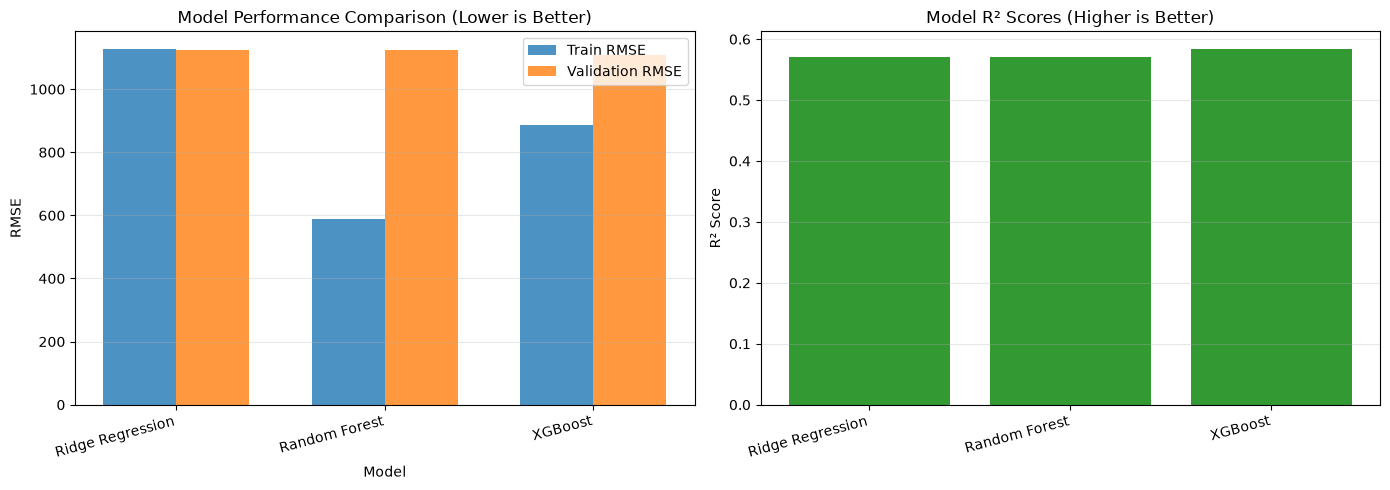

In [8]:
# visualiize performance
# Plot RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
models = comparison['Model'].values
x_pos = np.arange(len(models))
width = 0.35

axes[0].bar(x_pos - width/2, comparison['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[0].bar(x_pos + width/2, comparison['Validation RMSE'], width, label='Validation RMSE', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Model Performance Comparison (Lower is Better)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² comparison
axes[1].bar(models, comparison['R² Score'], alpha=0.8, color='green')
axes[1].set_ylabel('R² Score')
axes[1].set_title('Model R² Scores (Higher is Better)')
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Top 15 Features (XGBoost):
 Feature_Index  Importance
            25    0.252695
            26    0.243429
             2    0.124603
             3    0.093879
             6    0.025352
            17    0.020487
            21    0.017111
            20    0.016916
             4    0.016267
             1    0.013723
            12    0.013037
             9    0.012582
            13    0.012150
            11    0.012112
            19    0.012047


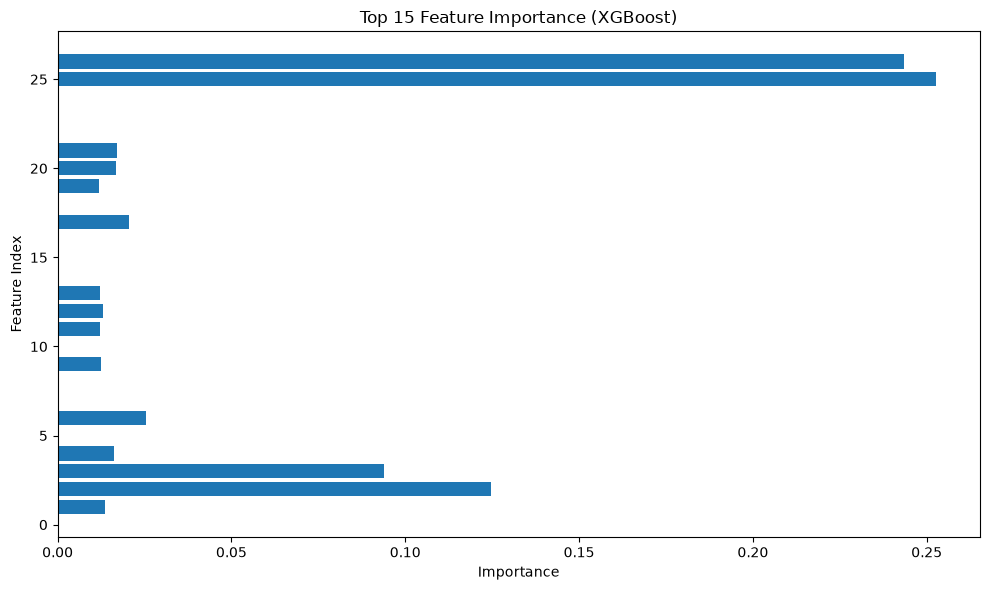

In [9]:
# check feature importance
# Get feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature_Index': range(len(xgb_model.feature_importances_)),
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print("\nTop 15 Features (XGBoost):")
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature_Index'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.title('Top 15 Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

In [10]:
# save the best model
# Save the best model
if best_model_name == 'Ridge Regression':
    best_model = ridge
elif best_model_name == 'Random Forest':
    best_model = rf
else:
    best_model = xgb_model

with open('/Users/EXOTISCH TECH/Desktop/dsn-bootcamp-hackathon/models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n✓ Best model ({best_model_name}) saved to models/best_model.pkl")


✓ Best model (XGBoost) saved to models/best_model.pkl


In [11]:
print("\n" + "="*70)
print("MODEL BUILDING PHASE COMPLETE")
print("="*70)
print(f"\n✓ Tested 3 models:")
print(f"  - Ridge Regression: {rmse_val_ridge:.4f} RMSE")
print(f"  - Random Forest: {rmse_val_rf:.4f} RMSE")
print(f"  - XGBoost: {rmse_val_xgb:.4f} RMSE")
print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Best Validation RMSE: {best_rmse:.4f}")
print(f"\nNext: Hyperparameter tuning on {best_model_name}")


MODEL BUILDING PHASE COMPLETE

✓ Tested 3 models:
  - Ridge Regression: 1123.4402 RMSE
  - Random Forest: 1123.2148 RMSE
  - XGBoost: 1107.1248 RMSE

✓ Best Model: XGBoost
✓ Best Validation RMSE: 1107.1248

Next: Hyperparameter tuning on XGBoost
